# part 1: preparation & pre_processing

In [1]:
import os
import re
import sys 
import time
import psutil
import ast
import math
import random


import numpy as np
from numpy.lib.stride_tricks import as_strided
import pandas as pd



import scipy.io
from scipy.optimize import minimize
from scipy.signal import butter, filtfilt
from scipy.special import comb
from scipy.ndimage.morphology import binary_dilation, binary_erosion
from scipy.signal import medfilt
from scipy.stats import norm
from scipy import signal,stats,interpolate

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.exceptions import DataConversionWarning

import warnings
import matplotlib.pyplot as plt


from collections import deque
from threading import Lock, Thread
from typing import List, Dict, Sized

In [2]:
warnings.filterwarnings(action='ignore', category= DataConversionWarning)
warnings.filterwarnings(action='ignore', category=UserWarning, message='Variables are collinear')


In [3]:
df = pd.read_csv("C:/Users/Niloo/Desktop/ges/emg_gestures-43-sequential-2018-04-25-08-29-12-311.csv")
df

,Unnamed: 0,EMG_1,EMG_2,EMG_3,EMG_4,EMG_5,EMG_6,EMG_7,EMG_8,EMG_9,...,EMG_19,EMG_20,EMG_21,EMG_22,EMG_23,EMG_24,TRAJ_1,TRAJ_GT_NO_FILTER,VIDEO_STAMP,TRAJ_GT
0,-0.073581,4.0,3.0,3.0,2.0,3.0,9.0,2.0,4.0,4.0,...,-4.0,2.0,3.0,2.0,-1.0,-2.0,-1.0,-1.0,-0.720296,-1.0
1,-0.073386,8.0,7.0,6.0,5.0,6.0,11.0,5.0,7.0,7.0,...,-3.0,3.0,3.0,4.0,2.0,0.0,-1.0,-1.0,-0.720100,-1.0
2,-0.073191,19.0,18.0,18.0,17.0,19.0,16.0,14.0,16.0,17.0,...,0.0,7.0,6.0,7.0,7.0,4.0,-1.0,-1.0,-0.719905,-1.0
3,-0.072996,24.0,24.0,25.0,23.0,24.0,20.0,19.0,22.0,22.0,...,1.0,9.0,7.0,9.0,10.0,7.0,-1.0,-1.0,-0.719710,-1.0
4,-0.072800,24.0,24.0,25.0,23.0,24.0,19.0,19.0,22.0,23.0,...,1.0,9.0,8.0,11.0,11.0,7.0,-1.0,-1.0,-0.719515,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347579,262.916275,-7.0,-8.0,-5.0,-5.0,-5.0,-2.0,0.0,-8.0,-8.0,...,-9.0,0.0,-5.0,-7.0,-10.0,-8.0,-1.0,-1.0,262.269560,-1.0
1347580,262.916470,-6.0,-7.0,-5.0,-4.0,-4.0,-2.0,0.0,-8.0,-7.0,...,-9.0,0.0,-5.0,-7.0,-9.0,-7.0,-1.0,-1.0,262.269755,-1.0
1347581,262.916665,-6.0,-6.0,-4.0,-5.0,-4.0,-3.0,1.0,-7.0,-6.0,...,-9.0,0.0,-5.0,-6.0,-9.0,-6.0,-1.0,-1.0,262.269951,-1.0
1347582,262.916860,-6.0,-7.0,-6.0,-5.0,-5.0,-4.0,0.0,-8.0,-6.0,...,-9.0,0.0,-4.0,-5.0,-8.0,-5.0,-1.0,-1.0,262.270146,-1.0


In [4]:
df.shape

(1347584, 29)

In [5]:
labels= df['TRAJ_GT']
labels

0         -1.0
1         -1.0
2         -1.0
3         -1.0
4         -1.0
          ... 
1347579   -1.0
1347580   -1.0
1347581   -1.0
1347582   -1.0
1347583   -1.0
Name: TRAJ_GT, Length: 1347584, dtype: float64

In [6]:
def moving_window_stride(array, window, step):

    stride = array.strides[0]
    win_count = math.floor((len(array) - window + step) / step)
    strided = as_strided(array, shape=(win_count, window), strides=(stride*step, stride))
    index = np.arange(window - 1, window + (win_count-1) * step, step)
    return strided, index


# Filtering

In [7]:
harmonic_x = lambda x, t: x[0] * np.sin(2 * np.pi * x[2] * t) + x[1] * (np.cos(2 * np.pi * x[2] * t))
harmonic_x_f = lambda x, t, f: x[0] * np.sin(2 * np.pi * f * t) + x[1] * (np.cos(2 * np.pi * f * t))
Q_x = lambda x, signal, t: np.sum([np.square(harmonic_x(x, t) - signal)]) / len(signal)
Q_x_f = lambda x, signal, t, f: np.sum([np.square(harmonic_x_f(x, t, f) - signal)]) / len(signal)


In [8]:
def Q_jacobian(x, signal, t):
    s = np.sin(2 * np.pi * x[2] * t)
    c = np.cos(2 * np.pi * x[2] * t)
    dx0 = 2 * np.sum([s * (x[0] * s + x[1] * c - signal)]) / len(signal)
    dx1 = 2 * np.sum([c * (x[0] * s + x[1] * c - signal)]) / len(signal)
    dx2 = 2 * np.sum([(2 * np.pi * t * x[0] * c + x[1] * (-2 * np.pi * t * s)) *
                      (x[0] * s + x[1] * c - signal)]) / len(signal)
    return np.array([dx0, dx1, dx2])


In [9]:
def Q_jacobian_f(x, signal, t, f):
    dx0 = 2 * np.sum([np.sin(2 * np.pi * f * t) * (
                x[0] * np.sin(2 * np.pi * f * t) + x[1] * (np.cos(2 * np.pi * f * t)) - signal)]) / len(signal)
    dx1 = 2 * np.sum([np.cos(2 * np.pi * f * t) * (
                x[0] * np.sin(2 * np.pi * f * t) + x[1] * (np.cos(2 * np.pi * f * t)) - signal)]) / len(signal)
   
    return np.array([dx0, dx1])


In [10]:
def multi_notch(series, window, notch_frequencies):
    windows_strided, indexes = moving_window_stride(series.values, np.int_(window), np.int_(window))
    indexes = np.append([0], indexes + 1)
    vec = np.zeros(np.shape(series))
    for freq in notch_frequencies:
        x_est = (0, 0, freq)
        i = 0
        for val in windows_strided:
            t0 = series.index[indexes[i]]
            t = np.arange(len(val)) / 5124.07211903 + t0
            bounds = ((None, None), (None, None), (freq - .01, freq + .01))
            res = minimize(Q_x, x_est, args=(val, t), method='L-BFGS-B', bounds=bounds, jac=Q_jacobian,
                           options={'gtol': 1e-6, 'disp': False})
            x_est = res.x
            vec[indexes[i]:indexes[i] + len(val)] += harmonic_x_f(x_est, t, x_est[2])
            x_est[2] = freq
            i = i + 1
    return vec

In [11]:
def butter_bandpass(low_cutoff, high_cutoff, fs, order=5):
    nyq = 0.5 * fs
    low = low_cutoff / nyq
    high = high_cutoff / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

In [12]:
def butter_bandpass_filter(data, low_cutoff, high_cutoff, fs, order=5):
    b, a = butter_bandpass(low_cutoff, high_cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

In [13]:
def pre_process(signal, window_t=10, freq=5124.07211903, low_pass=20, high_pass=700):
    notch_frequencies = [30, 49.99, 90, 60, 150]
    val = multi_notch(signal, window_t * freq, notch_frequencies)
    signal = butter_bandpass_filter(signal - val, low_pass, high_pass, freq)

    return signal


In [14]:
def apply_filter(df: pd.DataFrame):
    start = time.time()
    columns = list(filter(lambda k: 'EMG' in k, df.columns))
    print('Processing channel: ', end='', flush=True)
    for channel_name in columns:
        print(' ' + channel_name, end='', flush=True)
        df[channel_name] = pre_process(df[channel_name])
    print('', flush=True)
    print("Elapsed time: {:.2f}s".format(time.time() - start))


In [15]:
apply_filter(df)

Processing channel:  EMG_1 EMG_2 EMG_3 EMG_4 EMG_5 EMG_6 EMG_7 EMG_8 EMG_9 EMG_10 EMG_11 EMG_12 EMG_13 EMG_14 EMG_15 EMG_16 EMG_17 EMG_18 EMG_19 EMG_20 EMG_21 EMG_22 EMG_23 EMG_24
Elapsed time: 310.87s


# Feature extraction

In [16]:
w = 2500
s = 1250

In [17]:
def calculate_feature(df: pd.DataFrame, name, **kwargs):
    
    feature_func_name = 'feature_' + name.lower()
    feature_values = pd.DataFrame() 
    
    
    start = time.time()
    print('Calculating feature ' + name + ':', end='', flush=True)
    for column in df.filter(regex=r"EMG_\d+"): 
        print(' ' + column.split('_')[1], end='', flush=True)
        feature_label = name + '_' + column.split('_')[1]  
        
        feature = globals()[feature_func_name](df[column], **kwargs)
        if isinstance(feature, pd.Series):
            feature_values[feature_label] = feature
        elif isinstance(feature, pd.DataFrame):
            d = {}
            for c in feature.columns:
                d[c] = feature_label + "_" + c
            feature = feature.rename(columns=d)
            feature_values = feature_values.join(feature, how='outer')

    print('', flush=True)
    print("Elapsed time: {:.2f}s".format(time.time() - start))

    return feature_values

In [18]:
def window_trapezoidal(size, slope):
 
    if slope > 0.5:
        slope = 0.5
    if slope == 0:
        return np.full(size, 1)
    else:
        return np.array([1 if ((slope * size <= i) & (i <= (1-slope) * size)) else (1/slope * i / size) if (i < slope * size) else (1/slope * (size - i) / size) for i in range(1, size + 1)])


In [19]:
#root mean square (RMS)

def feature_rms(series, window, step):

    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.sqrt(np.mean(np.square(windows_strided), axis=1)), index=series.index[indexes])



# Hudgins & Dus feature sets

In [20]:
#mean absolute value (MAV)

#type1
def feature_mav1(series, window, step):
   
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    win_weight = [1 if ((0.25*window <= i) & (i <= 0.75*window)) else 0.5 for i in range(1, window+1)]
    return pd.Series(data=np.mean(np.abs(windows_strided) * win_weight, axis=1), index=series.index[indexes])


#type2
def feature_mav2(series, window, step):
   
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    win_weight = window_trapezoidal(window, 0.25)
    return pd.Series(data=np.mean(np.abs(windows_strided) * win_weight, axis=1), index=series.index[indexes])



def feature_mav(series, window, step):
 
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.mean(np.abs(windows_strided), axis=1), index=series.index[indexes])


In [21]:
#waveform length (WL)

def feature_wl(series, window, step):

    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.sum(np.diff(windows_strided), axis=1), index=series.index[indexes])



In [22]:
#zero crosssing (ZC)

def feature_zc(series, window, step, threshold):
  
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    zc = np.apply_along_axis(lambda x: np.sum(np.diff(x[(x < -threshold) | (x > threshold)] > 0)), axis=1,arr=windows_strided)
    return pd.Series(data=zc, index=series.index[indexes])


In [23]:
#slope sign change (SSC)

def feature_ssc(series, window, step, threshold):
   
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.apply_along_axis(lambda x: np.sum((np.diff(x[:-1]) * np.diff(x[1:])) <= -threshold), axis=1, arr=windows_strided), index=series.index[indexes])



In [24]:
#variance (VAR)

def feature_var(series, window, step):
    
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.var(windows_strided, axis=1), index=series.index[indexes])


In [25]:
#Willison amplitude (WAMP)

def feature_wamp(series, window, step, threshold):

    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.sum(np.diff(windows_strided) >= threshold, axis=1), index=series.index[indexes])


In [26]:
#integrated Electromyogram (iEMG): integral absolute value


def feature_iav(series, window, step):
    
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=np.sum(np.abs(windows_strided), axis=1), index=series.index[indexes])


In [27]:
rms = calculate_feature(df, name='RMS', window=w, step=s)


Calculating feature RMS: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.35s


In [28]:
def Hudgins_feature_set (df):
    m1 = calculate_feature(df, 'MAV1', window=w, step=s)
    m2 = calculate_feature(df, 'MAV2', window=w, step=s)
    m = calculate_feature(df, 'MAV', window=w, step=s)
    wl = calculate_feature(df, 'WL', window=w, step=s)
    z = calculate_feature(df, 'ZC', window=w, step=s, threshold=30)
    ssc = calculate_feature(df, 'SSC', window=w, step=s, threshold=16)
    
    hudgins = pd.concat([m1,m2,m,wl,z,ssc],axis=1)
    
    return hudgins


In [29]:
def Dus_feature_set (df):
    iav = calculate_feature(df, 'IAV', window=w, step=s)
    var = calculate_feature(df, 'VAR', window=w, step=s)
    wl = calculate_feature(df, 'WL', window=w, step=s)
    z = calculate_feature(df, 'ZC', window=w, step=s, threshold=30)
    ssc = calculate_feature(df, 'SSC', window=w, step=s, threshold=16)
    wamp = calculate_feature(df, 'WAMP', window=w, step=s, threshold=10)
    
    dus = pd.concat([iav,var,wl,z,ssc,wamp],axis=1)
    
    return dus


In [30]:
def filter_transitions(trajectory: np.ndarray,
                       start_before: int = 0, start_after: int = 0,
                       end_before: int = 0, end_after: int = 0,
                       pause_before: int = 0, pause_after: int = 0):
    trajectory_nan = trajectory.astype('float')
    np.putmask(trajectory_nan, trajectory_nan < 0, np.nan)

    diffs = np.concatenate(([0], np.diff(trajectory_nan)))
    np.putmask(diffs, np.isnan(diffs), 0)

    filtered = trajectory.copy()

    mask = np.full(trajectory.shape, False)
    if start_before > 0:
        start_before_mask = np.logical_and(diffs != 0, trajectory > 0)
        if start_before > 1:
            start_before_mask = binary_dilation(start_before_mask, structure=np.array([1, 1, 0]),
                                                iterations=start_before-1)
        mask = np.logical_or(mask, start_before_mask)

    if start_after > 0:
        start_after_mask = np.logical_and(diffs != 0, trajectory > 0)
        start_after_mask = binary_dilation(start_after_mask, structure=np.array([1, 0, 0]))  # shift left
        if start_after > 1:
            start_after_mask = binary_dilation(start_after_mask, structure=np.array([0, 1, 1]),
                                               iterations=start_after-1)
        mask = np.logical_or(mask, start_after_mask)

    if end_before > 0:
        end_before_mask = np.logical_and(diffs != 0, trajectory == 0)
        if end_before > 1:
            end_before_mask = binary_dilation(end_before_mask, structure=np.array([1, 1, 0]),
                                              iterations=end_before-1)
        mask = np.logical_or(mask, end_before_mask)

    if end_after > 0:
        end_after_mask = np.logical_and(diffs != 0, trajectory == 0)
        end_after_mask = binary_dilation(end_after_mask, structure=np.array([1, 0, 0]))  # shift left
        if end_after > 1:
            end_after_mask = binary_dilation(end_after_mask, structure=np.array([0, 1, 1]),
                                             iterations=end_after-1)
        mask = np.logical_or(mask, end_after_mask)

    filtered[mask] = -5

    pause_mask = trajectory == -1

    if pause_before > 0:
        pause_mask = binary_dilation(pause_mask, structure=np.array([1, 1, 0]), iterations=pause_before)
    if pause_after > 0:
        pause_mask = binary_dilation(pause_mask, structure=np.array([0, 1, 1]), iterations=pause_after)

    filtered[pause_mask] = -6

    return filtered


In [31]:
lab = pd.DataFrame(filter_transitions(df["TRAJ_GT"].values,
                                                 start_before=2, start_after=1,
                                                 end_before=0, end_after=0,
                                                 pause_before=0, pause_after=4))

def label(series, window, step):
    
    windows_strided, indexes = moving_window_stride(series.values, window, step)
    return pd.Series(data=labels, index=series.index[indexes])



# # part2: processing
# # spliting data

In [32]:
import itertools
import scipy.io as sio
import requests
from statsmodels.tsa.ar_model import AR

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import SVR

import matplotlib.patches as mpatches


# Training the data

In [33]:
#defines gestures 
rest= -1
idle= 0
fist= 1

flextion= 2
extension= 3

pinch_index= 6
pinch_middle= 7
pinch_ring= 8
pinch_small= 9

In [34]:
# define features set
f_set = {'hudgins', 'dus' , 'rms'}


In [35]:
#classifier function

def lda():
    return LinearDiscriminantAnalysis(solver='svd', shrinkage= None, priors= None, n_components= None,
                                      store_covariance= False, tol= 0.0001)

def qda():

    return QuadraticDiscriminantAnalysis(priors= None, reg_param= 0.3, store_covariance= False, 
                                         tol= 0.0001)

def knn():
    return KNeighborsClassifier(n_neighbors= 5, weights= 'uniform', algorithm='auto',
                                leaf_size= 30, p= 2, metric= 'minkowski', metric_params= None, n_jobs= None )

def svm():

    return SVC( 50, kernel = 'rbf', degree=3, gamma= 'auto', coef0= 0, shrinking= True, probability= False, 
               tol= 0.001, cache_size= 200, class_weight= None, verbose= False, max_iter= -1, 
               decision_function_shape= 'over', random_state= None) 


In [36]:
def spiliting_data(signal_features, signals_classes):
    x, x_test, y, y_test = train_test_split(signal_features, signals_classes, test_size=0.3, shuffle=False)
    
    # creat K-fold validation set, with 3 parts- for each experiment day, 4 combination are generated (results in 6 data combination for each subject)
    kf=KFold(n_splits= 4, shuffle= False, random_state= None)
    
    result_1= next(kf.split(x),None)
    
    x_train= x.iloc[result_1[0]]
    x_val= x.iloc[result_1[1]]
    
    result_2= next(kf.split(y),None)
    
    y_train= y.iloc[result_2[0]]
    y_val= y.iloc[result_2[1]]
    
    return x_train, x_val, x_test, y_train, y_val, y_test
    

In [37]:
def golden_seprate_1(prediction_class):
    prediction_classes_ = prediction_class.assign(time= [i for i in range(len(prediction_class))])[['time']+prediction_class.columns.tolist()]
    
    rest= prediction_classes_[prediction_classes_[0] != -1]
    idle= rest[rest[0] != 0]
    fist= idle[idle[0] != 1]
    flextion= fist[fist[0] != 2]
    extention= flextion[flextion[0] != 3]
    middle= extention[extention[0] != 7]
    ring= middle[middle[0] != 8]
    f_f_m_l=  ring[ring[0] != 9]
    return f_f_m_l


In [38]:
if 'dus' in f_set :
    #call spliting function
    x_train, x_val, x_test_du, y_train, y_val, y_test = spiliting_data(Dus_feature_set(df), label(lab, w, s))
     
    # call function (lda) from feature name list
    method_to_call = lda
    clf = method_to_call()
    clf.fit(x_train,  y_train)
    actual_classes = y_val 
    
    # predict & seprate golden labels
    prediction_classes1 = pd.DataFrame(clf.predict(x_val))
    f_f_m_l =  golden_seprate_1( prediction_classes1 )
    
    
    print(f_f_m_l)


Calculating feature IAV: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.36s
Calculating feature VAR: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.46s
Calculating feature WL: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.38s
Calculating feature ZC: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.68s
Calculating feature SSC: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.90s
Calculating feature WAMP: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.42s
     time    0
67     67  6.0
106   106  6.0
107   107  6.0
108   108  6.0
109   109  6.0
110   110  6.0
111   111  6.0
112   112  6.0
113   113  6.0
114   114  6.0
155   155  6.0
179   179  6.0


In [39]:
def golden_seprate_2(prediction_class):
    prediction_classes_2 = prediction_class.assign(time= [i for i in range(len(prediction_class))])[['time']+prediction_class.columns.tolist()]
    
    rest= prediction_classes_2[prediction_classes_2[0] != -1]
    idle= rest[rest[0] != 0]
    fist= idle[idle[0] != 1]
    flextion= fist[fist[0] != 2]
    index= flextion[flextion[0] != 6]
    middle= index[index[0] != 7]
    ring= middle[middle[0] != 8]
    ex= ring[ring[0] != 9]
    
    return ex

In [40]:
if 'hudgins' in f_set:
    
    #call spliting function
    x_train, x_val, x_test_hu, y_train, y_val, y_test = spiliting_data(Hudgins_feature_set(df), label(lab, w, s))
    
    # call function from feature name list
    method_to_call = qda 
    clf2 = method_to_call()
    clf2.fit(x_train,  y_train)

    # predict & seprate golden labels
    prediction_classes2 = pd.DataFrame(clf2.predict(x_val))
    ex = golden_seprate_2(prediction_classes2)
    
    print(ex)


Calculating feature MAV1: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.60s
Calculating feature MAV2: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.57s
Calculating feature MAV: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.36s
Calculating feature WL: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.38s
Calculating feature ZC: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.66s
Calculating feature SSC: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
Elapsed time: 0.88s
     time    0
37     37  3.0
44     44  3.0
45     45  3.0
56     56  3.0
57     57  3.0
58     58  3.0
59     59  3.0
60     60  3.0
80     80  3.0
81     81  3.0
82     82  3.0
83     83  3.0
84     84  3.0
85     85  3.0
86     86  3.0
87     87  3.0
88     88  3.0
89     89  3.0
91     91  3.0
92     92  3.0
93     93  3.0
132   132  3.0
180   1

In [41]:
def golden_seprate_3(prediction_class):
    prediction_classes_3 = prediction_class.assign(time= [i for i in range(len(prediction_class))])[['time']+prediction_class.columns.tolist()]
    
    rest = prediction_classes_3[prediction_classes_3[0] != -1]
    fist = rest[rest[0] != 1]
    flextion = fist[fist[0] != 2]
    extention= flextion[flextion[0] != 3]
    index= extention[extention[0] != 6]
    p_i_r =  index[index[0] != 7]
    return p_i_r



In [42]:
def golden_seprate_4(prediction_class):
    prediction_classes_4 = prediction_class.assign(time= [i for i in range(len(prediction_class))])[['time']+prediction_class.columns.tolist()]
    
    rest= prediction_classes_4[prediction_classes_4[0] != -1]
    idle = rest[rest[0] != 0]
    fist = idle[idle[0] != 1]
    extention= fist[fist[0] != 3]
    index= extention[extention[0] != 6]
    ring= index[index[0] != 8]
    idle_0_ = ring[ring[0] != 9]
    
    return idle_0_

In [43]:
def golden_seprate_5(prediction_class):
    prediction_classes_5 = prediction_class.assign(time= [i for i in range(len(prediction_class))])[['time']+prediction_class.columns.tolist()]
    
    rest= prediction_classes_5[prediction_classes_5[0] != -1]
    idle = rest[rest[0] != 0]
    flextion = idle[idle[0] != 2]
    extention= flextion[flextion[0] != 3]
    index= extention[extention[0] != 6]
    middle= index[index[0] != 7]
    ring= middle[middle[0] != 8]
    fl_p_r = ring[ring[0] != 9]
    
    return fl_p_r

In [44]:
if 'rms' in f_set:
    
    #call spliting function
    x_train, x_val, x_test_rms, y_train, y_val, y_test = spiliting_data(rms, label(lab, w, s))
    
    # call function from feature name list
    method_to_call = qda 
    clf3 = method_to_call()
    clf3.fit(x_train,  y_train)

    # predict & seprate golden labels
    prediction_classes3 = pd.DataFrame(clf3.predict(x_val))
    p_i_r = golden_seprate_3(prediction_classes3)
    
    
    # call function from feature name list
    method_to_call =knn 
    clf4 = method_to_call()
    clf4.fit(x_train,  y_train)

    # predict & seprate golden labels
    prediction_classes4 = pd.DataFrame(clf4.predict(x_val))
    idle_0_ = golden_seprate_4(prediction_classes4)
    
    # call function from feature name list
    method_to_call = svm
    clf5 = method_to_call()
    clf5.fit(x_train,  y_train)

    # predict & seprate golden labels
    prediction_classes5 = pd.DataFrame(clf5.predict(x_val))
    fle = golden_seprate_5(prediction_classes5)
    
    print(p_i_r,idle_0_,fle)


     time    0
4       4  0.0
7       7  0.0
8       8  0.0
9       9  0.0
10     10  0.0
..    ...  ...
184   184  9.0
185   185  9.0
186   186  9.0
187   187  9.0
188   188  9.0

[130 rows x 2 columns]      time    0
44     44  2.0
56     56  2.0
57     57  2.0
58     58  2.0
59     59  2.0
61     61  2.0
62     62  2.0
63     63  2.0
64     64  7.0
65     65  7.0
66     66  2.0
130   130  7.0
131   131  7.0
133   133  7.0
136   136  7.0
137   137  7.0
181   181  2.0     time    0
32    32  1.0
33    33  1.0
34    34  1.0
35    35  1.0
36    36  1.0
37    37  1.0
38    38  1.0
39    39  1.0
40    40  1.0
41    41  1.0
42    42  1.0
43    43  1.0


In [45]:

def gathering(f_f_m_l_label, p_i_r_label, idle_lable,e_label,fle_label,actual_classes_len):
    pr = p_i_r_label.append(fle_label).append( f_f_m_l_label).append(e_label).append(idle_lable).sort_values('time',ascending=True,kind="mergesort")
    pred_fin = pr[~pr.duplicated(['time'],keep='last')]
    
    if len(pred_fin) != len(actual_classes_len):
        for_r_l = pd.DataFrame(zip(*[range(len(actual_classes_len))]), columns=[0])
        for_all_r = pd.DataFrame(zip(*[range(len(actual_classes_len))]), columns=['time'])
        def example(x):
            x[0]=-1
            return x
        for_r_l = for_r_l.apply(example, axis=1)
    
        for_all_r[0]=for_r_l
    
    
    all_pr =  pred_fin.append(for_all_r).sort_values('time',ascending=True,kind="mergesort")
    finall_val_pr = all_pr[~all_pr.duplicated(['time'],keep='first')]
    finall_val_pr = finall_val_pr[0]
    
    return finall_val_pr


In [46]:
finall_val_pr = gathering(f_f_m_l, p_i_r, idle_0_,ex,fle,actual_classes)
print(classification_report(actual_classes,finall_val_pr ))

              precision    recall  f1-score   support

        -1.0       0.46      0.32      0.37        19
         0.0       0.75      0.87      0.81        86
         1.0       1.00      0.85      0.92        13
         2.0       0.80      0.67      0.73        12
         3.0       0.67      0.92      0.77        13
         6.0       0.75      0.69      0.72        13
         7.0       0.57      0.33      0.42        12
         8.0       1.00      0.92      0.96        12
         9.0       1.00      0.78      0.88         9

    accuracy                           0.76       189
   macro avg       0.78      0.70      0.73       189
weighted avg       0.75      0.76      0.75       189



# Evaluation

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix

In [48]:
# confusion metrics
print('confusion matrix:')
print(confusion_matrix (actual_classes, finall_val_pr, labels=[-1,0,1,2,3,6,7,8,9]))

confusion matrix:
[[ 6 13  0  0  0  0  0  0  0]
 [ 7 75  0  0  2  1  1  0  0]
 [ 0  0 11  1  1  0  0  0  0]
 [ 0  0  0  8  1  1  2  0  0]
 [ 0  1  0  0 12  0  0  0  0]
 [ 0  4  0  0  0  9  0  0  0]
 [ 0  7  0  0  1  0  4  0  0]
 [ 0  0  0  0  0  1  0 11  0]
 [ 0  0  0  1  1  0  0  0  7]]


# Curves

In [49]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [50]:
actual_classes_bin = label_binarize(actual_classes, classes=[-1,0,1,2,3,6,7,8,9])
n_classes=9
finall_val_pr_bin = label_binarize(finall_val_pr, classes=[-1,0,1,2,3,6,7,8,9])

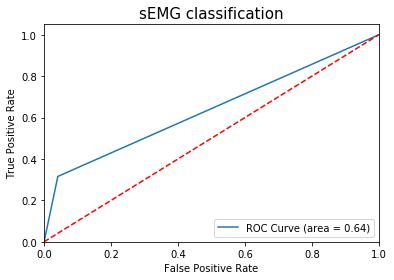

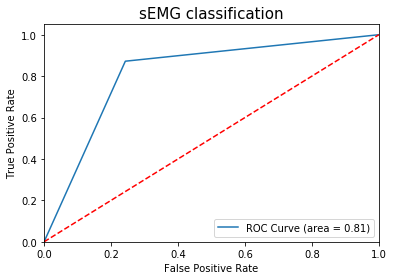

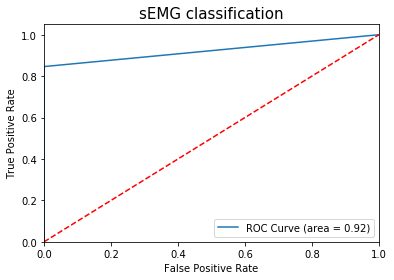

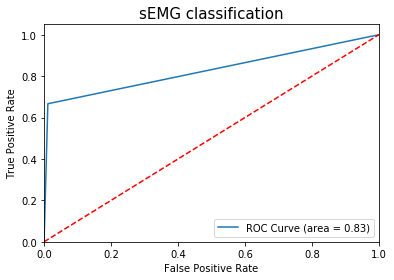

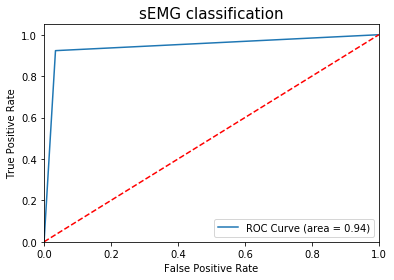

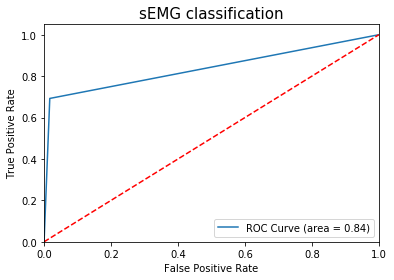

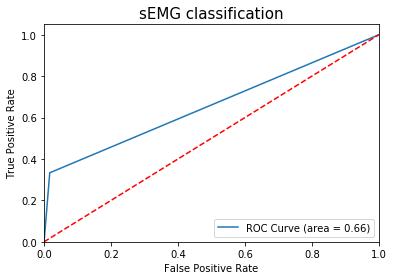

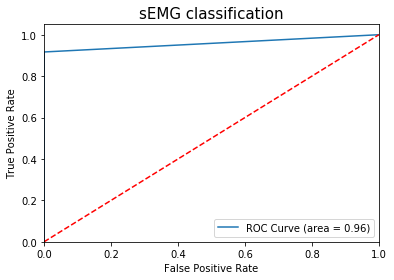

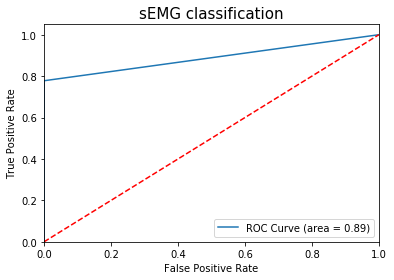

In [51]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i],_ = roc_curve(actual_classes_bin[:,i],finall_val_pr_bin[:,i])
    roc_auc[i] = auc(fpr[i],tpr[i])

for i in range(n_classes):
    plt.figure()
    plt.plot(fpr[i], tpr[i], label='ROC Curve (area = %0.2f)'%roc_auc[i])
    plt.plot([0,1],[0,1],color='r',linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('sEMG classification',size=15)
    plt.legend(loc="lower right")
    plt.show()

# prediction for test data

In [52]:

def predicting_test_labels (x_du,x_hu,x_rms,y_labels):
    #predict labels for dus data features
    pre_classes_1 = pd.DataFrame(clf.predict(x_du))
    f_f_m_l_t =  golden_seprate_1(pre_classes_1)
    
    #predict labels for Hudgins data features
    pre_classes_2 = pd.DataFrame(clf2.predict(x_hu))
    ex_t = golden_seprate_2(pre_classes_2)
    
     #predict labels for RMS data features
    pre_classes_3 = pd.DataFrame(clf3.predict(x_rms))
    p_i_r_t = golden_seprate_3(pre_classes_3)
    
   
    pre_classes_4 = pd.DataFrame(clf4.predict(x_rms))
    idle_0_t = golden_seprate_4(pre_classes_4)
    
    pre_classes_5 = pd.DataFrame(clf5.predict(x_rms))
    fle_t = golden_seprate_5(pre_classes_5)
    
    finall_test_labels = gathering(f_f_m_l_t, p_i_r_t, idle_0_t,ex_t,fle_t,y_labels)
    return finall_test_labels


In [53]:
finall_test_labels = predicting_test_labels (x_test_du,x_test_hu,x_test_rms,y_test)
print('y_predict:\n', finall_test_labels ,'\n\n\n y_test:\n',y_test)

y_predict:
 0      0.0
1     -1.0
2     -1.0
3      0.0
4      0.0
      ... 
319   -1.0
320   -1.0
321   -1.0
322   -1.0
323   -1.0
Name: 0, Length: 324, dtype: float64 


 y_test:
 943749     0.0
944999     0.0
946249     0.0
947499     0.0
948749     0.0
          ... 
1342499   -1.0
1343749   -1.0
1344999   -1.0
1346249   -1.0
1347499   -1.0
Name: TRAJ_GT, Length: 324, dtype: float64


In [54]:
print(classification_report(y_test,finall_test_labels ))

              precision    recall  f1-score   support

        -1.0       0.44      0.27      0.33        41
         0.0       0.78      0.90      0.84       169
         1.0       1.00      0.25      0.40         4
         2.0       0.88      0.78      0.82        18
         3.0       0.86      1.00      0.93        19
         6.0       0.65      0.94      0.77        18
         7.0       0.60      0.50      0.55        18
         8.0       1.00      0.41      0.58        17
         9.0       1.00      0.85      0.92        20

    accuracy                           0.76       324
   macro avg       0.80      0.66      0.68       324
weighted avg       0.76      0.76      0.74       324

